## Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

## Data Load and Preprocessing

In [57]:
df = pd.read_csv("rent.csv")
X = df.drop(["price"], axis=1)
y = df["price"]

[0.41658396 0.52174744 0.36338369 0.46293474]
1.0330814613468517


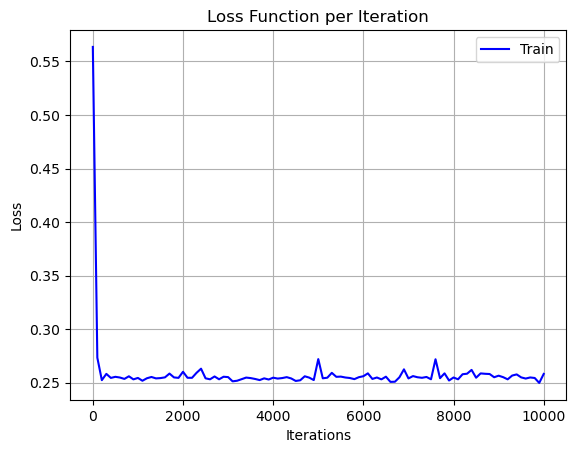

In [4]:
trainX = pd.DataFrame([(0, 0), (0, 1), (1, 0), (1, 1)], columns=["in1", "in2"])
trainY = pd.DataFrame([1, 0, 0, 1], columns=["output"])
testX = pd.DataFrame([(0, 0), (0, 1), (1, 0), (1, 1)], columns=["in1", "in2"])
testY = [1, 0, 0, 1]
mse = []
epochs = range(1, 10002, 100)

for n in epochs:
    mlp = MLPRegressor(hidden_layer_sizes=(2, ), activation='logistic', max_iter=n, solver="sgd", learning_rate_init=0.001)
    mlp.fit(trainX, trainY)

    pred = mlp.predict(testX)
        
    sum = 0
    for ind, error in enumerate(list(pred)):
        sum += (error - testY[ind])**2

    if n == epochs[-1]:
        print(pred)
        print(sum)
        
    mse.append(sum/4)

plt.plot(epochs, mse, color="b", label="Train")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Function per Iteration")
plt.legend()
plt.grid(True)
plt.show()

## 5.)

In [71]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)

lr = make_pipeline(StandardScaler(), LinearRegression())
mlp_nact = make_pipeline(StandardScaler(), 
                         MLPRegressor(hidden_layer_sizes=(5, 5), activation='identity', max_iter=1000))
mlp_act = make_pipeline(StandardScaler(), 
                        MLPRegressor(hidden_layer_sizes=(5, 5), activation='relu', max_iter=1000))

lr_mae_scores = -cross_val_score(lr, X, y, cv=cv, scoring='neg_mean_absolute_error')
nact_mae_scores = -cross_val_score(mlp_nact, X, y, cv=cv, scoring='neg_mean_absolute_error')
act_mae_scores = -cross_val_score(mlp_act, X, y, cv=cv, scoring='neg_mean_absolute_error')

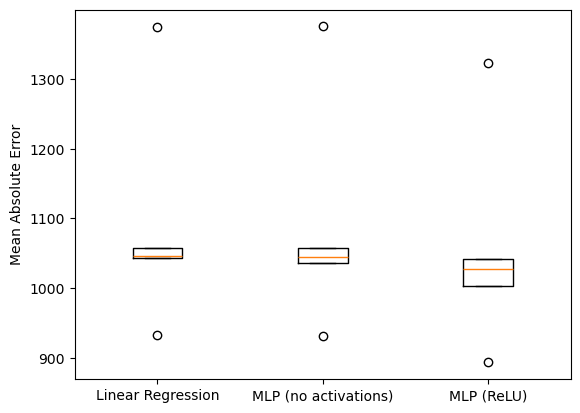

Linear regression mean MAE scores: 1090.872329122922
MLP with no activationsmean MAE scores: 1089.0974046104302
MLP with ReLU activation mean MAE scores: 1057.8288375588654


In [74]:
plt.boxplot([lr_mae_scores, nact_mae_scores, act_mae_scores])
plt.xticks([1, 2, 3], ['Linear Regression', 'MLP (no activations)', 'MLP (ReLU)'])
plt.ylabel('Mean Absolute Error')
plt.show()

print(f"Linear regression mean MAE scores: {lr_mae_scores.mean()}")
print(f"MLP with no activationsmean MAE scores: {nact_mae_scores.mean()}")
print(f"MLP with ReLU activation mean MAE scores: {act_mae_scores.mean()}")

## 7.)

In [83]:
warnings.filterwarnings(action='ignore', category=ConvergenceWarning)

cv = KFold(n_splits=5, shuffle=True, random_state=0)
max_iter = 500
n_folds = 5
train_losses = []
val_losses = []

for fold, (train_index, test_index) in enumerate(cv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    mlp = MLPRegressor(hidden_layer_sizes=(5, 5), activation='relu', max_iter=max_iter,
                       early_stopping=True, validation_fraction=0.2, n_iter_no_change=max_iter+1)

    mlp.fit(X_train_scaled, y_train)
    train_curve = np.array(mlp.loss_curve_)
    val_scores = np.array(mlp.validation_scores_)

    y_train_var = np.var(y_train)
    val_curve = (1 - val_scores) * y_train_var

    train_losses.append(train_curve)
    val_losses.append(val_curve)

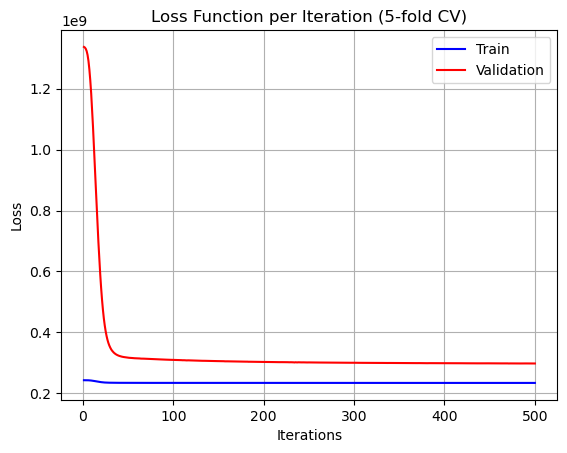

In [89]:
avr_train_loss = np.array(train_losses).mean(axis=0)
avr_val_loss = np.array(val_losses).mean(axis=0)
iterations = range(1, max_iter + 1)

plt.plot(iterations, avr_train_loss, color="b", label="Train")
plt.plot(iterations, avr_val_loss, color="r", label="Validation")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Function per Iteration (5-fold CV)")
plt.legend()
plt.grid(True)
plt.show()